本 Notebook 展示了如何创建“计划-执行”风格的智能体。这很大程度上受到了 Plan-and-Solve 论文以及 Baby-AGI 项目的启发。

核心思想是首先制定一个多步计划，然后一次执行计划中的一个项目。完成某个特定任务后，您可以重新审视该计划并酌情修改。

一般的计算图如下所示
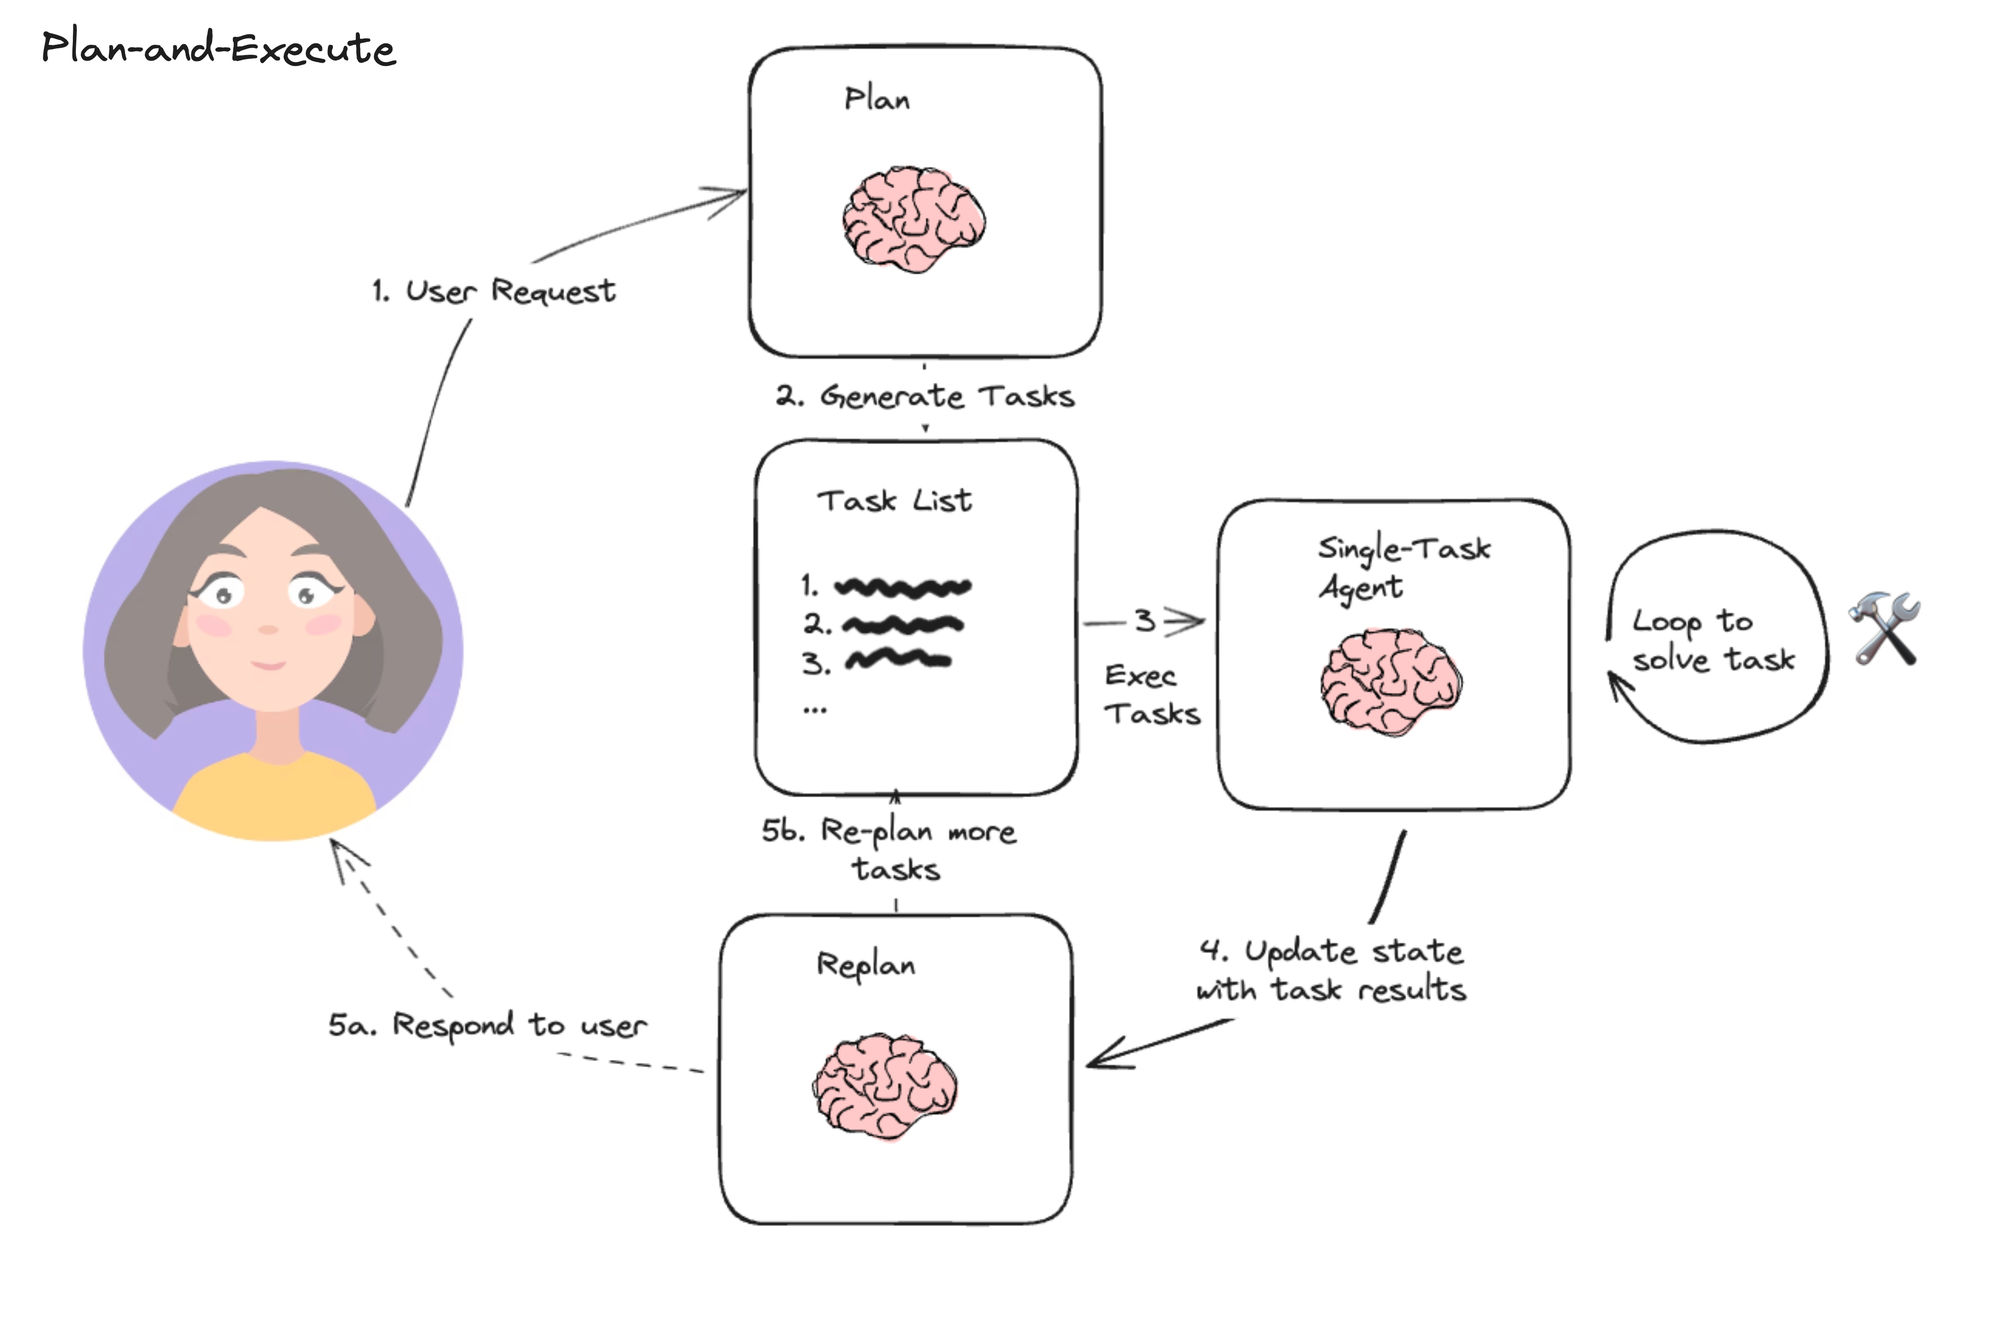

In [1]:
import getpass
import os
import pprint


def _set_if_undefined(var: str) -> None:
    if os.environ.get(var):
        return
    os.environ[var] = getpass.getpass(var)


_set_if_undefined("ANTHROPIC_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

In [2]:
from langchain.chat_models import init_chat_model
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent

tools = [TavilySearchResults(max_results=3)]

llm = init_chat_model(
    model="deepseek-v4-pro",
    model_provider="anthropic",
    base_url="https://api.deepseek.com/anthropic", # 必须补充此核心参数
    temperature=0)

agent_executor = create_agent(llm, tools,system_prompt="You are a helpful assistant.")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_49832\3490115424.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\Administrator\AppData\Local\Temp\ipykernel_49832\3490115424.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tools = [TavilySearchResults(max_results=3)]


In [3]:
agent_executor.invoke({"messages": [("user", "who is the winnner of the us open")]})

{'messages': [HumanMessage(content='who is the winnner of the us open', additional_kwargs={}, response_metadata={}, id='dd585d92-ba7f-46a3-beb9-6830bfccd3f5'),
  AIMessage(content=[{'signature': 'c328c161-511b-4b38-9dc8-82200cbde343', 'thinking': 'The user is asking about the winner of the US Open. However, "US Open" could refer to several different tournaments - tennis (US Open), golf (US Open), or other sports. Since they didn\'t specify, and given the timing, I should search for recent results. Let me search for the most recent US Open winners across both tennis and golf to provide a comprehensive answer.\n\nActually, let me think about the timing. The current date appears to be 2025 based on the system prompt saying "Current date: 2025-10-14". \n\n- The US Open tennis typically takes place in August-September. So the 2025 US Open tennis would have just finished.\n- The US Open golf typically takes place in June. So the 2025 US Open golf would have already happened.\n\nLet me search

## 定义状态
现在我们开始定义此智能体需要跟踪的状态。

首先，我们需要跟踪当前计划。我们将其表示为一个字符串列表。

接下来，我们应该跟踪先前执行的步骤。我们将其表示为一个元组列表（这些元组将包含步骤和结果）

最后，我们需要一些状态来表示最终响应和原始输入。

In [4]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

In [5]:
from pydantic import BaseModel, Field

class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

In [16]:
def make_llm():
    return ChatAnthropic(
        model_name="deepseek-v4-pro",
        temperature=0,
        base_url="https://api.deepseek.com/anthropic",
        thinking={"type":"disabled"}
    )


In [19]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_anthropic import ChatAnthropic
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
               This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
               The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.""",
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | make_llm().with_structured_output(Plan)

## 重新规划步骤
现在，我们创建一个根据上一步结果重新制定计划的步骤。

In [20]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)


replanner  = replanner_prompt | make_llm().with_structured_output(Act)

## 创建图


In [8]:
from typing import Literal
from langgraph.graph import END


async def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}


async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}


def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "agent"

In [10]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)

# Add the plan node
workflow.add_node("planner", plan_step)

# Add the execution step
workflow.add_node("agent", execute_step)

# Add a replan node
workflow.add_node("replan", replan_step)

workflow.add_edge(START, "planner")

# From plan we go to agent
workflow.add_edge("planner", "agent")

# From agent, we replan
workflow.add_edge("agent", "replan")

workflow.add_conditional_edges(
    "replan",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["agent", END],
)

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

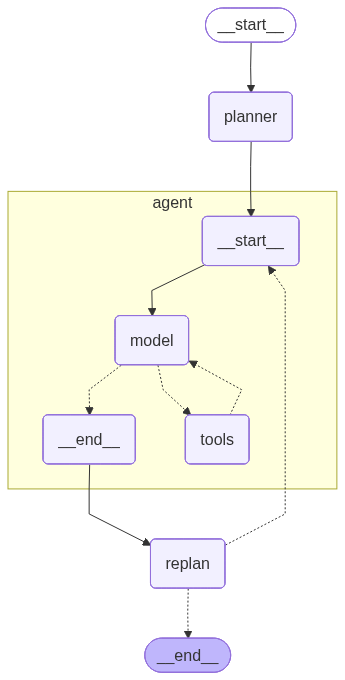

In [12]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [22]:
def format_step(step_type, value):
    """根据节点输出类型，渲染成可读文本。"""
    BAR = "─" * 56

    # ── planner / replan 产出的计划 ──
    if "plan" in value:
        plan = value["plan"]
        lines = ["📋 制定计划" if step_type == "planner" else "🔄 更新计划", BAR]
        for i, s in enumerate(plan, 1):
            lines.append(f"  {i}. {s}")
        return "\n".join(lines)

    # ── agent 执行步骤的结果 ──
    if "past_steps" in value:
        out = []
        for task, result in value["past_steps"]:
            out.append("⚙️  执行步骤")
            out.append(BAR)
            out.append(f"  任务：{task}")
            # result 可能是字符串，也可能是消息块列表（含 thinking/text）
            thinking, text = _extract_blocks(result)
            if thinking:
                out.append(f"\n  💭 思考：{thinking.strip()}")
            if text:
                out.append(f"\n  📝 结果：\n{_indent(text.strip())}")
        return "\n".join(out)

    # ── replan 最终答复 ──
    if "response" in value:
        return f"✅ 最终答复\n{BAR}\n{_indent(value['response'].strip())}"

    return str(value)


def _extract_blocks(result):
    """从 result 里抽出 thinking 和 text。result 可能是 str 或 [块,...]。"""
    if isinstance(result, str):
        return "", result
    thinking, text = "", ""
    if isinstance(result, list):
        for block in result:
            if isinstance(block, dict):
                if block.get("type") == "thinking":
                    thinking += block.get("thinking", "")
                elif block.get("type") == "text":
                    text += block.get("text", "")
            else:
                text += str(block)
    else:
        text = str(result)
    return thinking, text


def _indent(s, prefix="    "):
    """给多行文本统一缩进。"""
    return "\n".join(prefix + line for line in s.splitlines())

In [25]:
config = {"recursion_limit": 50}
inputs = {"input": "what is the hometown of the mens 2024 Australia open winner?"}
async for event in app.astream(inputs, config=config):
    for k, v in event.items():
        if k == "__end__":
            continue
        print("\n" + format_step(k, v) + "\n")


📋 制定计划
────────────────────────────────────────────────────────
  1. Identify the winner of the men's singles at the 2024 Australian Open.
  2. Find the hometown of that player.


⚙️  执行步骤
────────────────────────────────────────────────────────
  任务：Identify the winner of the men's singles at the 2024 Australian Open.

  💭 思考：The search results clearly show that Jannik Sinner of Italy won the men's singles at the 2024 Australian Open. He defeated Daniil Medvedev in a five-set final: 3-6, 3-6, 6-4, 6-4, 6-3.

So step 1 is complete: the winner is Jannik Sinner.

  📝 结果：
    **Step 1 Result:**
    
    The winner of the men's singles at the **2024 Australian Open** was **Jannik Sinner** of Italy. He defeated Daniil Medvedev in a five-set final (3–6, 3–6, 6–4, 6–4, 6–3) to claim his first Grand Slam title. This also made him the first Italian man or woman to win an Australian Open singles title in the Open Era.


🔄 更新计划
────────────────────────────────────────────────────────
  1. Find t